<BarContainer object of 30 artists>

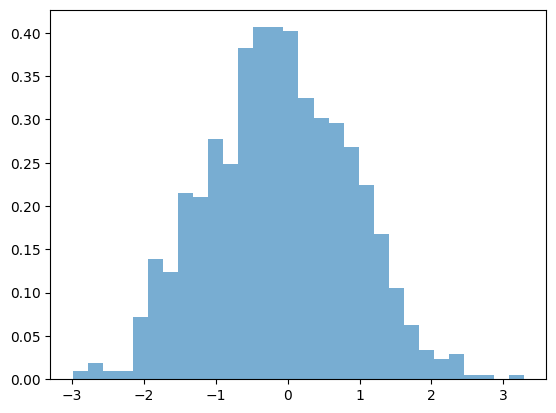

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rp1(M, N):
    a = 0.02
    b = 5.0

    Mc = np.ones((M, 1)) * b * np.sin(np.arange(1, N + 1) * np.pi / N)
    Ac = a * np.ones((M, 1)) * np.arange(1, N + 1) # Offset

    v = (np.random.rand(M, N) - 0.5) * Mc + Ac # Zero mean noise applied to deterministic sin wave
    return v

def rp2(M, N): # All rows have the same value
    Ar = np.random.rand(M, 1) * np.ones((1, N)) # Constant in offset for each realisation.
    Mr = np.random.rand(M, 1) * np.ones((1, N)) # Constant in amplitude for each realisation.

    v = (np.random.rand(M, N) - 0.5) * Mr + Ar # Zero mean noise applied to non-deterministic noise
    return v

def rp3(M, N):
    a = 0.5 
    m = 3.0

    v = (np.random.rand(M, N) - 0.5) * m + a # All realisations are random. Same distribution across time and realisations. Ergodic process.
    return v

def pdf(v, bins=50):
    counts, edges = np.histogram(v, bins=bins, density=False)
    dx = edges[1] - edges[0]
    p = counts / (np.sum(counts) * dx)
    x = edges[:-1]
    return p, x

N = 1000
v = np.random.randn(N)

p, x = pdf(v, bins=30)

plt.bar(x, p, width=x[1]-x[0], alpha=0.6, label="Estimated PDF")

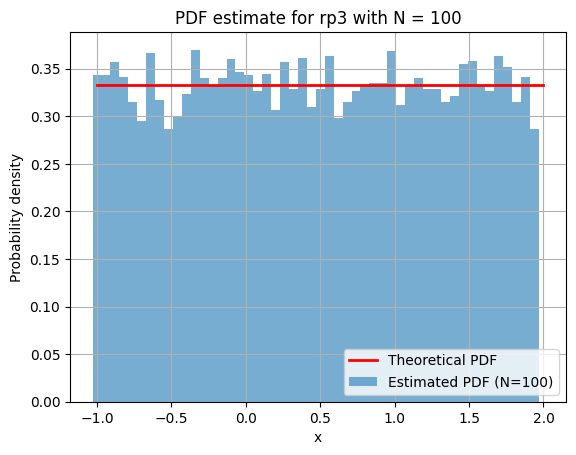

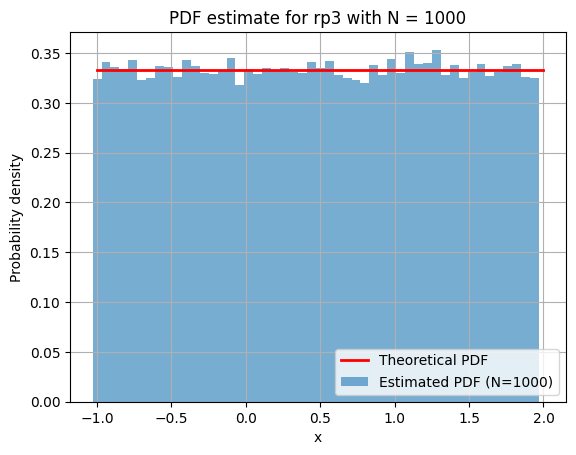

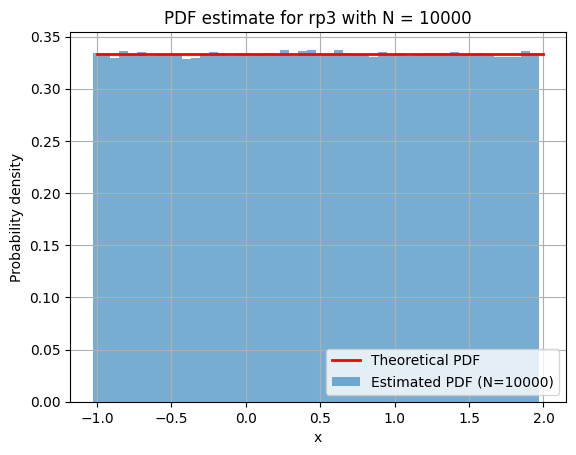

In [11]:
M = 100
N_list = [100, 1000, 10000]
process_3 = rp3(M, N)

a = 0.5
m = 3.0

x_th = np.linspace(a - m/2, a + m/2, 500)
pdf_th = np.ones_like(x_th) / m

for N in N_list:
    process_3 = rp3(M, N)
    p, x = pdf(process_3, bins=50)

    plt.figure()
    plt.bar(x, p, width=x[1] - x[0], alpha=0.6,
            label=f"Estimated PDF (N={N})")
    plt.plot(x_th, pdf_th, 'r', linewidth=2,
             label="Theoretical PDF")

    plt.xlabel("x")
    plt.ylabel("Probability density")
    plt.title(f"PDF estimate for rp3 with N = {N}")
    plt.legend()
    plt.grid(True)


As data length increases, estimated PDF converges to the theoretical PDF. Variance converges towards 0. 

The PDF function assumes that all samples come from the same underlying distribution, and so is therefore a stationary process. Therefore, with a non-stationary process with a varying PDF, the resulting PDF will be a time average mixture as a histogram forgets the time index of samples. 

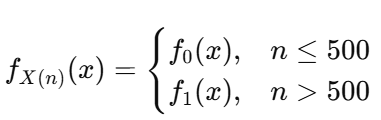

You can have two seperate sample groups from the two different pdf's and plot them seperately. 